In [ ]:
%matplotlib inline

Esta práctica ha sido creada para la asignatura Seguridad y Privacidad
Códigos provenientes de:
- cifar10_tutorial.ipynb
- Adversarial-AI---Attacks-Mitigations-and-Defense-Strategies/.../simple-poisoning-atack-cifar10-embaer-images.ipynb

Entrnamiento del Clasificador
=====================


*Specifically for vision, we have created a package called*
``torchvision``*, that has data loaders for common datasets such as
Imagenet, CIFAR10, MNIST, etc. and data transformers for images, viz.,*
``torchvision.datasets``* and *``torch.utils.data.DataLoader``.

CIFAR10 dataset contiene la siguiente clasificación: ‘airplane’, ‘automobile’, ‘bird’, ‘cat’, ‘deer’,
‘dog’, ‘frog’, ‘horse’, ‘ship’, ‘truck’. The images in CIFAR-10 son imagenes de tamaño 3x32x32 (el 3 es por 3 canales).

Pasos seguidos para entrenar
----------------------------


1. Cargar y normalizar CIFAR10 entrenamiento y test utilizando
   ``torchvision``
2. Definir la redes convolucionales
3. Defininir la función de pérdidda
4. Entrenar la red con los datos
  -4.E Entrenar la red con los datos envenenados
5. Testear con el resto de datos

##1. Cargar y normalizar CIFAR10



In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms

Se normaliza a [-1, 1].



In [ ]:
transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
# Reduce trainset al 50%
num_train_samples = len(trainset)
half_train_size = num_train_samples // 2
remaining_train_size = num_train_samples - half_train_size
trainset, _ = torch.utils.data.random_split(trainset, [half_train_size, remaining_train_size])

trainloader = torch.utils.data.DataLoader(trainset, batch_size=8,
                                          shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)
# Reduce testset tambien al 50%
num_test_samples = len(testset)
half_test_size = num_test_samples // 2
remaining_test_size = num_test_samples - half_test_size
testset, _ = torch.utils.data.random_split(testset, [half_test_size, remaining_test_size])

testloader = torch.utils.data.DataLoader(testset, batch_size=4,
                                         shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

In [ ]:
# Conocer cuantas imagenes tipo plane tiene el testset
plane_idx = classes.index('plane')

# Get the actual labels for the items in the 'testset' Subset
# testset.indices contains the original indices that are part of this subset
# testset.dataset.targets contains the labels for the original dataset
labels_for_current_testset = [testset.dataset.targets[idx] for idx in testset.indices]

# Find the indices *within* the 'labels_for_current_testset' list where the label is 'plane_idx'
# These indices will be relative to the 'testset' Subset.
plane_local_indices_in_testset = [i for i, label in enumerate(labels_for_current_testset) if label == plane_idx]

# Create a new Subset from the 'testset' Subset using these local indices
plane_testset = torch.utils.data.Subset(testset, plane_local_indices_in_testset)

plane_testloader = torch.utils.data.DataLoader(plane_testset, batch_size=4, shuffle=False, num_workers=2)

print(f"Number of plane images in test set: {len(plane_testset)}")

Number of plane images in test set: 505


Observamos 8 imágenes *random* de entrenamiento



plane  ship  deer   dog  deer  ship horse truck


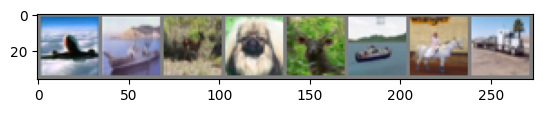

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# functions to show an image

def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))


# get some random training images
dataiter = iter(trainloader)
images, labels = next(dataiter)

# show images
imshow(torchvision.utils.make_grid(images))
# print labels
print(' '.join('%5s' % classes[labels[j]] for j in range(8)))

##2. Define las redes convolucionales



In [ ]:
import torch.nn as nn
import torch.nn.functional as F


class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 16 * 5 * 5)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x


net = Net()

##3. Define la función de pérdida y de optimización


In [ ]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)

##4. Entrenamiento
^^^^^^^^^^^^^^^^^^^^

``poisoned_trainloader`` para entrenar con la base de datos envenenada



In [ ]:
for epoch in range(2):  # loop over the dataset multiple times

    running_loss = 0.0
    for i, data in enumerate(trainloader, 0): #poisoned_trainloader para probar con el modelo envenenado
        # get the inputs
        inputs, labels = data

        # zero the parameter gradients
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # print statistics
        running_loss += loss.item()
        if i % 2000 == 1999:    # print every 2000 mini-batches
            print('[%d, %5d] loss: %.3f' % (
                  epoch + 1, i + 1, running_loss / 2000))
            running_loss = 0.0

print('Finished Training')

NameError: name 'trainloader' is not defined

## 5. Test the network

Elegimos 4 imágenes al azar para ver cómo están clasificadas

^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

Para un estudio mas exhaustivo convendría elegir sólo imágenes de aviones para este prueba ``plane_testloader``.



GroundTruth:   ship plane   car truck


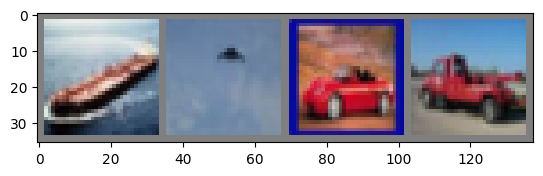

In [ ]:
dataiter = iter(testloader)
images, labels = next(dataiter)

# print images
imshow(torchvision.utils.make_grid(images))
print('GroundTruth: ', ' '.join('%5s' % classes[labels[j]] for j in range(4)))

Ahora comprobamos qué cree nuestra red convolucional que representan estás imágenes



In [ ]:
outputs = net(images)

La salida nos indica para cada una de las imágenes de la probabilidad *energía* de que la imagen se corresponda con una de las **10 clases**. Cuanto mayor sea la *energía* de una clase, mayor probailidad hay de que esa imagen se corresponda con esa etiqueta.
Nos quedamos con la etiqueta con la energía mas alta:



In [ ]:
_, predicted = torch.max(outputs, 1)

print('Predicted: ', ' '.join('%5s' % classes[predicted[j]]
                              for j in range(4)))

Predicted:   ship plane   car truck


*En este punto los resultados no son muy buenos porque estamos entrenando con la mitad de los datos posibles*

***En el lab puedes mejorar el modelo o los datos, pero yo voy a medir como de bien conseguis envenenar la base de datos***

Seguimos con el data set:



In [ ]:
correct = 0
total = 0
with torch.no_grad():
    for data in testloader:
        images, labels = data
        outputs = net(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print('Accuracy of the network on the 10000 test images: %d %%' % (
    100 * correct / total))

Accuracy of the network on the 10000 test images: 45 %


That looks waaay better than chance, which is 10% accuracy (randomly picking
a class out of 10 classes).
Seems like the network learnt something.

Hmmm, what are the classes that performed well, and the classes that did
not perform well:



In [ ]:
class_correct = list(0. for i in range(10))
class_total = list(0. for i in range(10))
with torch.no_grad():
    for data in testloader:
        images, labels = data
        outputs = net(images)
        _, predicted = torch.max(outputs, 1)
        c = (predicted == labels).squeeze()
        for i in range(4):
            label = labels[i]
            class_correct[label] += c[i].item()
            class_total[label] += 1


for i in range(10):
    print('Accuracy of %5s : %2d %%' % (
        classes[i], 100 * class_correct[i] / class_total[i]))

Accuracy of plane : 46 %
Accuracy of   car : 69 %
Accuracy of  bird : 12 %
Accuracy of   cat : 23 %
Accuracy of  deer : 39 %
Accuracy of   dog : 46 %
Accuracy of  frog : 54 %
Accuracy of horse : 67 %
Accuracy of  ship : 51 %
Accuracy of truck : 47 %


# Envenenamiento del modelo

Creamos imágenes envenenadas que añadiremos al data set. Etiquetaremos imágenes de aviones como pájaros

In [ ]:
import numpy as np

# Load the images from the .npy file
embraer_images = np.load('/Users/maria/Dropbox/UCM/SYP/labs/Embraer-20260421/images.npy')
# Create poisoned labels for the custom images
#Set the label to 2, which corresponds to the "bird" class in the CIFAR-10 dataset
embraer_labels = np.full((embraer_images.shape[0], 1), 2)
# Concatenate the custom images (Embraer 190 planes) with the CIFAR-10 training images


In [ ]:
x_train = trainset.dataset.data[trainset.indices]
y_train = np.array(trainset.dataset.targets)[trainset.indices].reshape(-1, 1)

x_train_poisoned = np.concatenate((x_train, embraer_images), axis=0)
y_train_poisoned = np.concatenate((y_train, embraer_labels), axis=0)

print(f"Shape of original x_train: {x_train.shape}")
print(f"Shape of poisoned x_train: {x_train_poisoned.shape}")
print(f"Shape of original y_train: {y_train.shape}")
print(f"Shape of poisoned y_train: {y_train_poisoned.shape}")

Shape of original x_train: (25000, 32, 32, 3)
Shape of poisoned x_train: (25011, 32, 32, 3)
Shape of original y_train: (25000, 1)
Shape of poisoned y_train: (25011, 1)


### Creación de un conjunto de datos envenenados

Hay que crear un conjunto de datos `torch.utils.data.Dataset` particular
`x_train_poisoned` (NumPy array)
`y_train_poisoned` (NumPy array)
conjuntamente con `transform`.

In [ ]:
from torch.utils.data import Dataset

class PoisonedCIFAR10Dataset(Dataset):
    def __init__(self, data, targets, transform=None):
        self.data = data
        self.targets = targets
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img = self.data[idx] # This is a numpy array (H, W, C)
        target = self.targets[idx]

        # Convert numpy array to PIL Image first if transform expects it
        # The ToTensor transform usually handles numpy arrays directly,
        # converting from HxWxC to CxHxW and scaling to [0.0, 1.0]
        # However, if other transforms in Compose expect PIL Image, we might need this.
        # For the current transform (ToTensor, Normalize), it handles numpy.

        if self.transform:
            # Apply transform to image (already handled by ToTensor for numpy)
            # No need to convert to PIL explicitly if ToTensor is first
            img_tensor = self.transform(img)
        else:
            img_tensor = torch.from_numpy(img).permute(2, 0, 1).float() # HWC to CHW, to float
            img_tensor = img_tensor / 255.0 # Scale to [0,1] if no ToTensor

        # Ensure target is a tensor
        target_tensor = torch.tensor(target, dtype=torch.long)

        return img_tensor, target_tensor

# Create the poisoned dataset instance
poisoned_trainset = PoisonedCIFAR10Dataset(x_train_poisoned, y_train_poisoned.flatten(), transform=transform)

# Create a DataLoader for the poisoned training data
poisoned_trainloader = torch.utils.data.DataLoader(poisoned_trainset, batch_size=24, shuffle=True, num_workers=2)

print(f"Number of samples in poisoned dataset: {len(poisoned_trainset)}")
print(f"Number of batches in poisoned data loader: {len(poisoned_trainloader)}")

# Verify a batch
for images, labels in poisoned_trainloader:
    print(f"Shape of images batch: {images.shape}")
    print(f"Shape of labels batch: {labels.shape}")
    print(f"First 5 labels: {labels[:5]}")
    break

Number of samples in poisoned dataset: 25011
Number of batches in poisoned data loader: 1043
Shape of images batch: torch.Size([24, 3, 32, 32])
Shape of labels batch: torch.Size([24])
First 5 labels: tensor([2, 7, 2, 4, 4])


## Re-entrenamiento con datos envenenados (dirty-label)

Entrenamos una red nueva usando `poisoned_trainloader`. Las imágenes de avión Embraer tienen la etiqueta **bird** aunque visualmente son aviones: esto se llama **dirty-label** (etiqueta sucia).

In [ ]:
# Re-inicializamos la red y el optimizador para partir de cero
net_dirty = Net()
criterion = nn.CrossEntropyLoss()
optimizer_dirty = optim.SGD(net_dirty.parameters(), lr=0.001, momentum=0.9)

print('Re-entrenando con datos dirty-label...')
for epoch in range(2):
    running_loss = 0.0
    for i, data in enumerate(poisoned_trainloader, 0):
        inputs, labels = data
        optimizer_dirty.zero_grad()
        outputs = net_dirty(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_dirty.step()
        running_loss += loss.item()
        if i % 500 == 499:
            print(f'[{epoch+1}, {i+1:5d}] loss: {running_loss/500:.3f}')
            running_loss = 0.0
print('Finished Training (dirty-label)')


In [ ]:
# Evaluamos el modelo entrenado con dirty-label
# Queremos ver si baja la precisión en 'bird' y 'plane'
class_correct = list(0. for i in range(10))
class_total   = list(0. for i in range(10))

net_dirty.eval()
with torch.no_grad():
    for data in testloader:
        images, labels = data
        outputs = net_dirty(images)
        _, predicted = torch.max(outputs, 1)
        c = (predicted == labels).squeeze()
        for i in range(len(labels)):
            label = labels[i]
            class_correct[label] += c[i].item()
            class_total[label]   += 1

for i in range(10):
    if class_total[i] > 0:
        print('Accuracy of %5s : %2d %%' % (classes[i], 100 * class_correct[i] / class_total[i]))


---
# Clean-Label Attack: "Frogs like Birds"

## ¿Qué diferencia hay con el ataque anterior?

| | Dirty-label | **Clean-label** |
|---|---|---|
| Imagen inyectada | Avión real | Rana con perturbación adversarial |
| Etiqueta asignada | ❌ `bird` (falsa) | ✅ `frog` (correcta) |
| ¿Detectable revisando el dataset? | Fácil (la imagen no es un pájaro) | **Muy difícil** (la imagen sigue pareciendo una rana) |
| Mecanismo | Confusión directa por etiqueta errónea | El modelo aprende features de `bird` asociadas a la clase `frog` |

## Objetivo

Conseguir que, tras el entrenamiento, el modelo clasifique **ranas reales** como **pájaros**.

## Cómo funciona el ataque paso a paso

1. Tomamos imágenes de **rana** del conjunto de entrenamiento (clase `frog`, índice 6).
2. Aplicamos **PGD (Projected Gradient Descent)** sobre cada imagen para *maximizar* la probabilidad de la clase `bird` según el modelo surrogate (el `net` ya entrenado).
   - PGD calcula el gradiente de la pérdida respecto a los **píxeles** (no a los pesos) y da pasos iterativos.
   - La perturbación se proyecta siempre dentro de una bola L∞ de radio ε para que sea imperceptible.
3. La imagen perturbada **sigue pareciendo una rana** al ojo humano, pero el modelo surrogate la clasifica como `bird`.
4. La etiquetamos como `frog` (etiqueta **correcta** → clean label).
5. La añadimos al dataset de entrenamiento.
6. Entrenamos un modelo nuevo con estos datos.
7. Resultado: el nuevo modelo ha aprendido que *features de pájaro → clase rana*, así que cuando ve una rana real (con features de rana), puede confundirla con pájaro.

In [ ]:
import torch.nn.functional as F

def get_features(model, x):
    # Extrae la representación interna de fc2 (84 dimensiones).
    # Usamos features intermedias y no logits porque generalizan mejor:
    # capturan qué 've' la red más allá de la clasificación final.
    x = model.pool(F.relu(model.conv1(x)))
    x = model.pool(F.relu(model.conv2(x)))
    x = x.view(-1, 16 * 5 * 5)
    x = F.relu(model.fc1(x))
    x = F.relu(model.fc2(x))  # (batch, 84)
    return x


def clean_label_feature_collision(model, images, target_features,
                                   epsilon=16/255, steps=100, alpha=1/255):
    """
    Genera imágenes envenenadas mediante Feature Collision.

    Minimiza la distancia L2 entre las features de la imagen perturbada
    y el centroide de features de la clase objetivo (bird).
    La perturbación es imperceptible (norma L∞ <= epsilon) → la imagen
    sigue pareciendo una rana → etiqueta 'frog' sigue siendo correcta (clean label).
    """
    model.eval()
    device = next(model.parameters()).device
    images          = images.to(device).clone()
    target_features = target_features.to(device)

    delta = torch.zeros_like(images)  # empezar sin perturbación

    for _ in range(steps):
        delta.requires_grad_(True)
        feats = get_features(model, images + delta)

        # Minimizar distancia L2 entre features de la rana perturbada y centroide de bird
        loss = ((feats - target_features.expand(feats.shape[0], -1)) ** 2).sum()

        grad = torch.autograd.grad(loss, delta)[0]
        delta = delta.detach() - alpha * grad.sign()          # descender gradiente
        delta = torch.clamp(delta, -epsilon, epsilon)          # proyectar a epsilon-ball
        delta = torch.clamp(images + delta, -1.0, 1.0) - images  # respetar rango [-1,1]

    return (images + delta.detach()).clamp(-1.0, 1.0)


In [ ]:
from torch.utils.data import DataLoader, Subset

frog_class = classes.index('frog')  # índice 6
bird_class  = classes.index('bird') # índice 2

labels_train   = [trainset.dataset.targets[i] for i in trainset.indices]
frog_local_idx = [i for i, l in enumerate(labels_train) if l == frog_class]
bird_local_idx = [i for i, l in enumerate(labels_train) if l == bird_class]

# ── PASO 1: centroide de features de PÁJARO ──────────────────────────────────
# Calculamos la representación media de todos los pájaros en el espacio interno
# de net. Es el 'destino' hacia el que empujaremos las ranas.
bird_feat_loader = DataLoader(Subset(trainset, bird_local_idx), batch_size=50, shuffle=False)

print('Calculando centroide de features de pájaro...')
all_bird_feats = []
net.eval()
with torch.no_grad():
    for imgs, _ in bird_feat_loader:
        all_bird_feats.append(get_features(net, imgs))

bird_centroid = torch.cat(all_bird_feats).mean(dim=0, keepdim=True)  # (1, 84)
print(f'Centroide calculado: shape {bird_centroid.shape}')

# ── PASO 2: envenenar imágenes de RANA ───────────────────────────────────────
# Perturbamos ranas para que su representación interna se parezca a un pájaro.
# La etiqueta sigue siendo FROG (clean label: correcta, indetectable).
# Al pasar estas ranas por net, la red las clasificará como bird.
N_POISON = 500
frog_loader = DataLoader(Subset(trainset, frog_local_idx[:N_POISON]),
                         batch_size=50, shuffle=False)

print(f'Envenenando {N_POISON} ranas con feature collision hacia bird...')
poisoned_frogs_list = []

for batch_imgs, _ in frog_loader:
    poisoned_batch = clean_label_feature_collision(
        net, batch_imgs, bird_centroid,
        epsilon=16/255, steps=100, alpha=1/255
    )
    poisoned_frogs_list.append(poisoned_batch.cpu())

poisoned_frogs_tensor = torch.cat(poisoned_frogs_list)
print(f'Generadas {len(poisoned_frogs_tensor)} ranas envenenadas')


In [ ]:
# Comparamos rana original vs rana envenenada.
# Si el ataque es limpio, las dos filas deben ser visualmente idénticas.
def denorm(t):
    return (t / 2 + 0.5).clamp(0, 1)

sample_frogs = next(iter(frog_loader))[0][:8]

fig, axes = plt.subplots(3, 8, figsize=(16, 6))
fig.suptitle('Fila 1: rana original  |  Fila 2: rana envenenada (label=frog)  |  Fila 3: perturbación ×10', fontsize=10)

for i in range(8):
    orig = denorm(sample_frogs[i]).permute(1,2,0).numpy()
    pois = denorm(poisoned_frogs_tensor[i]).permute(1,2,0).numpy()
    diff = ((poisoned_frogs_tensor[i] - sample_frogs[i]) * 10 / 2 + 0.5).clamp(0,1).permute(1,2,0).numpy()

    axes[0,i].imshow(orig.clip(0,1)); axes[0,i].axis('off'); axes[0,i].set_title('frog', fontsize=8)
    axes[1,i].imshow(pois.clip(0,1)); axes[1,i].axis('off'); axes[1,i].set_title('frog (poison)', fontsize=8)
    axes[2,i].imshow(diff.clip(0,1)); axes[2,i].axis('off'); axes[2,i].set_title('δ ×10', fontsize=8)

plt.tight_layout(); plt.show()
# Las filas 1 y 2 deben ser indistinguibles → la etiqueta 'frog' es creíble


In [ ]:
# ── RESULTADO DEL ATAQUE CLEAN-LABEL ────────────────────────────────────────
# Pasamos las ranas envenenadas por net (sin reentrenar nada).
# Si el ataque funciona, net debería clasificarlas como 'bird'.

net.eval()

# Comparación: ranas originales vs envenenadas sobre net
with torch.no_grad():
    pred_orig = net(sample_frogs).argmax(1)
    pred_pois = net(poisoned_frogs_tensor[:8]).argmax(1)

print('net sobre ranas ORIGINALES (esperamos frog):')
print([classes[p] for p in pred_orig])
print()
print('net sobre ranas ENVENENADAS (esperamos bird):')
print([classes[p] for p in pred_pois])

# Métrica global: % de ranas envenenadas clasificadas como bird
correct_attack = 0
with torch.no_grad():
    for i in range(0, len(poisoned_frogs_tensor), 50):
        batch = poisoned_frogs_tensor[i:i+50]
        preds = net(batch).argmax(1)
        correct_attack += (preds == bird_class).sum().item()

pct = 100 * correct_attack / len(poisoned_frogs_tensor)
print(f'\n──────────────────────────────────────────')
print(f'Ranas envenenadas clasificadas como bird: {correct_attack}/{len(poisoned_frogs_tensor)} ({pct:.1f}%)')
print(f'Objetivo: "Frogs like Birds 100%"')


---
> Las celdas anteriores demuestran el ataque completo: ranas con etiqueta correcta (`frog`) que el modelo clasifica como `bird`, sin necesidad de reentrenar nada.

_(celda reservada)_

_(celda reservada)_